![banner.png](attachment:banner.png)

# Aplicaciones de Redes Convolucionales - Semana 6
## _Transfer Learning_ para nuevas tareas usando redes pre-entrenadas en Keras
### Laboratorio Sumativo

### Propósito de la actividad
En esta actividad mostraremos cómo usar redes convolucionales para visión computacional que ya han sido pre-entrenadas con grandes cantidades de datos, pero que quieren ser usadas con unos nuevos datos y para una tarea diferente.

Esto corresponde a la aplicación de _transfer learning_, en donde se remueven las últimas capas de una red pre-entrenada, y después de ponen nuevas capas entrenables adicionales. En _Keras_ este proceso también se conoce como _fine tunning_.

Otra opción, que es muy parecida al _transfer learning_ es usar capas intermedias de una red pre-entrenada y calcular las variables transformadas hasta esta capa. Estas variables, se pueden convertir en una nueva muestra de entrenamiento para un modelo de _machine learning_. En _Keras_ este proceso se conoce como _feature extraction_.


### Instrucciones generales

El laboratorio contiene dos partes, la primera (A) consiste en la explicación de _transfer learning_ usando la red VGG16, y la segunda (B) corresponde a la asignación del laboratorio sumativo.

Para la segunda parte, debe realizar la entrega correspondiente con la solución.

### Librerías a importar

A continuación se muestran los comandos a ejecutar para poder implementar los procedimientos de este notebook:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#Las siguientes dos líneas evitan la generación de "warnings" y "flags" al importar keras y tensorflow.
#Dichas advertencias no comprometen el funcionamiento del código.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#Importación de keras y tensorflow
import tensorflow as tf
import tensorflow_datasets as tfds
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.models import Sequential

### A. Uso de _CNN_ pre-entrenada para Aprendizaje por Transferencia

La estructura de modelo secuencial tipo CNN puede ser importada directamente sin necesidad de definir cada una de las capas, como conv2D, MaxPooling, etc. Muchas redes pueden ser implementadas automáticamente desde _Keras_ (https://keras.io/api/applications/). Sin embargo, muchas veces estas redes son bastante genéricas. Por ejemplo, muchas de ellas han sido entrenadas con los datos de _IMAGENET_ para clasificación multiclase, pero con alrededor de 1000 clases diferentes. Cuando requerimos un uso más específico, por ejemplo, reconocer la marca de un vehículo o el tipo de ambiente en una fotografía, este tipo de clasificación genérica no nos funciona muy bien.

La opción más directa, es hacer nuestra propia red convolucional desde cero con nuestros propios datos. Para esto, podemos tomas como inspiración muchas de las arquitecturas que ya han sido probadas (AlexNet, VGG16, GoogleNEt, ResNet, etc.). Sin embargo, es posible que, dado que nuestros datos corresponden a una aplicación más especializada, no tengamos a nuestra disposición la cantidad suficiente de imágenes para entrenar nuestra red.

Otra opción más útil, sería usar como base de nuestro modelo, una red ya pre-entrenada. Por ejemplo, las primeras capas de una red tipo ResNet. El principio de este enfoque, es que las primeras capas todavía no se han especilizado completamente y son bastante genéricas en términos de reconocer patrones básicos que pueden funcionar en diversos problemas. Para estas primeras capas tomamos los pesos (estimación de los parámetros) ya fijos (recordemos que tenemos la opción de definir el parámetro "weights"). Sobre estas capas, podemos adicionar unas nuevas capas (generalmente son del tipo completamente conectadas) y entrenar los pesos de estas con los datos que tenemos a disposición para nuestro problema.

Dentro de la calibración de los modelos de _Transfer Learning_, aparecen entonces nuevos hiper-parámetros que son necesarios de calibrar, como el número de capas del modelo base ya preentrenado y el número de capas entrenables adicionales. Esto depende, por supuesto, de la cantidad de imágenes que tengamos disponibles y de la complejidad de la tarea.

#### _Transfer Learning_ en Keras usando VGG16

La forma más sencilla de usar _transfer learning_ con redes pre-entrenadas, es cargando la red con los pesos fijos, como por ejemplo en el modelo VGG16, usando  `weights='imagenet'`, que incluye los valores de todos los parámetros ya entrenados con los datos descritos del ILSVRC. Sin embargo, en este caso el parámetro `include_top`, que hace referencia a si se incluyen las últimas 3 capas de tipo completamente conectadas (_fully connected_) se define como `False`, dado que se reemplazarán por capas nuevas.

Además de esto, es necesario añadir las capas nuevas con las cuales crearemos nuestro modelo. Una vez se tiene la configuración del modelo, se fijan los valores de las primeras capas, haciendo para cada una de las _layers_ que no se entrenan `layer.trainable = False`.

Miremos la implementación usando la red VGG16 contenida en _Keras Applications_:

In [36]:
#Importar modelo entrenado VGG16 con las últimas capas
#Puede tomar algunos segundos
vgg = VGG16(input_shape=(224,224,3), weights='imagenet', include_top=False)
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Sobre este modelo, el primer paso (que es opcional), es usar una operación de _pooling_ global sobre la salida de la última capa ("block5_pool"), para pasar a una arreglo en una dimensión de tamaño [1,1,512].

In [38]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base=GlobalAveragePooling2D()(vgg.output)

Después, se pueden adicionar capas completamente conectadas ("Dense") de diferentes tamaños. En este caso, añadimos una capa de 256 nodos con activación RELU:

In [40]:
new=Dense(256,activation='relu')(base)

De la misma forma, es posible adicionar capas adicionales.

Supongamos que el nuevo problema que queremos resolver es de reconocimiento de imágenes con 5 clases diferentes de objetos. Para esto, es necesario crear la capa de salida:

In [41]:
out_layer=Dense(5,activation='softmax')(new)

El último paso antes de compilar el modelo, es fijar las capas cuyos pesos queremos que se mantengan fijos, mientras que las capas restantes se dejan libres para entrenar. En este caso, todas las capas anteriores del VGG16 a las capas completamente conectadas se dejarán fijas:

In [42]:
for layer in vgg.layers:
    layer.trainable = False

Ahora se puede definir el nuevo modelo que va desde los _inputs_ del modelo base (VGG) hasta la capa de salida definida:

In [43]:
from tensorflow.keras.models import Model

model=Model(inputs=vgg.input,outputs=out_layer)

Y con esto, ya es posible compilar el modelo. En este caso usamos _Adam_ con un problema de clasificación multiclase. Puede ser definido a conveniencia para calibrar el modelo en términos de hiper-parámetros:

In [52]:
from keras.optimizers import Adam
model.compile(optimizer= Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.995), loss='SparseCategoricalCrossentropy', metrics=['accuracy'])

***
#### Problema de reconocimiento de imágenes y datos a usar

En este caso, resolveremos un problema de identificación de especies de flores. Se tienen 5 diferentes especies que salen en los datos: daisy (margarita), dandelion (diente de león), roses (rosas), sunflowers (girasoles), y tulips (tulipanes). La base de datos contiene en total 3670 imágenes en color  y se obtiene directamente de un repositorio usando las herramientas de Tensorflow para carga de datos:

In [11]:
import pathlib

archive = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    extract=True
)

base_path = pathlib.Path(archive).parent

extracted_dir = base_path / "flower_photos.tgz" / "flower_photos"

print("Ruta final:", extracted_dir)
print("¿Existe?:", extracted_dir.exists())
print("Clases:", [item.name for item in extracted_dir.iterdir()])

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Ruta final: /root/.keras/datasets/flower_photos.tgz/flower_photos
¿Existe?: True
Clases: ['tulips', 'daisy', 'LICENSE.txt', 'sunflowers', 'roses', 'dandelion']


Miremos primero el número total de imágenes:

In [12]:
image_count = len(list(extracted_dir.glob('*/*.jpg')))
print(image_count)

3670


Y algunas imágenes de muestra:

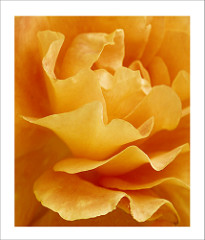

In [13]:
import PIL
import PIL.Image
roses = list(extracted_dir.glob('roses/*'))
PIL.Image.open(str(roses[1]))

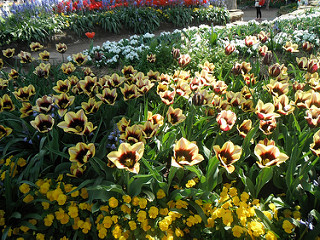

In [14]:
import PIL
import PIL.Image
roses = list(extracted_dir.glob('tulips/*'))
PIL.Image.open(str(roses[4]))

Ahora definimos los datos para entrenamiento y para validación (`train_ds` y `val_ds` respectivamente) usando un tamaño de 224 por 224, para que sea compatible con VGG16:

In [45]:
batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Revisemos las dimensiones en cada uno de los conjuntos de datos:

In [46]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


Por último, antes de usar los datos, los escalamos para que estén en el rango [0,1], y no tengamos problemas en el entrenamiento:

In [47]:
from tensorflow.keras import layers

scale_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (scale_layer(x), y))
val_ds = val_ds.map(lambda x, y: (scale_layer(x), y))

Con estos elementos ya es posible entrenar el modelo usando "model.fit". _Nota:_ El "warning" referente al uso de funciones `lambda` no representa un problema ni afecta la ejecución del código y será eliminado en próximas versiones de Tensorflow.

A continuación, se entrenará el modelo compilado. Dicho entrenamiento puede tomar algunas horas, por lo que es posible que el kernel de Coursera se cierre por el largo tiempo de ejecución. Se sugiere ejecutar el código en un computador local, aún mejor con acceso a GPU para una ejecución mucho más rápida. Otra opción bastante útil, es el uso de Google Colaboratory solicitando los recursos de GPU. Consulte la lectura _"Lectura 4: Uso de Google Colab para ejecución de Jupyter Notebooks con GPU"_ para guiarse en el proceso en caso de dudas.

In [53]:
epochs = 10
model_train = model.fit(train_ds,epochs=epochs,verbose=1,validation_data=val_ds)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 700ms/step - accuracy: 0.9598 - loss: 0.1260 - val_accuracy: 0.8992 - val_loss: 0.4520
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 687ms/step - accuracy: 0.9789 - loss: 0.0559 - val_accuracy: 0.8869 - val_loss: 0.3982
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 688ms/step - accuracy: 0.9697 - loss: 0.0894 - val_accuracy: 0.8747 - val_loss: 0.4671
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 691ms/step - accuracy: 0.9576 - loss: 0.1235 - val_accuracy: 0.8978 - val_loss: 0.4591
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 693ms/step - accuracy: 0.9831 - loss: 0.0550 - val_accuracy: 0.8733 - val_loss: 0.4454
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 689ms/step - accuracy: 0.9837 - loss: 0.0446 - val_accuracy: 0.9264 - val_loss: 0.2943
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 689ms/step - accuracy: 0.9951 - loss: 0.0181 - val_accuracy: 0.9264 - val_loss: 0.4203
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 688ms/step - accuracy: 0.9898 - loss: 0.0344 - val_accu

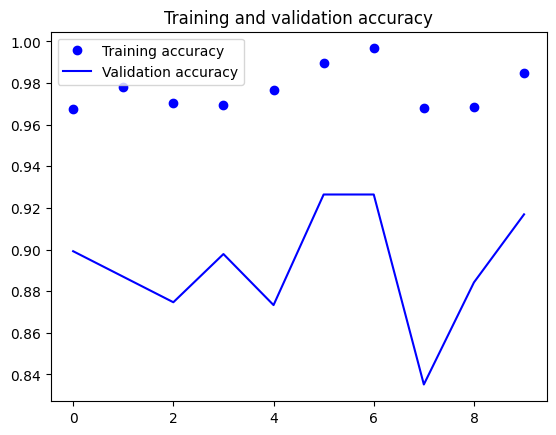

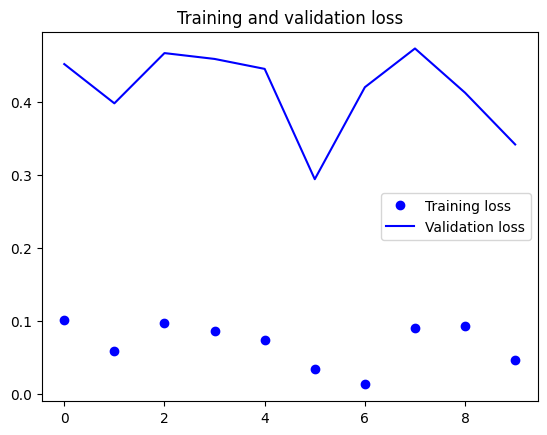

In [54]:
accuracy = model_train.history['accuracy']
val_accuracy = model_train.history['val_accuracy']
loss = model_train.history['loss']
val_loss = model_train.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

***
### B. Laboratorio Sumativo _Transfer Learning_

El laboratorio consiste en hacer _transfer learning_ usando los datos de flores que se cargaron y con la partición que se hizo para entrenamiento y validación. Sin embargo, en lugar de usar la red VGG16, usaremos la red Inception, la cual también está disponible en Keras (https://keras.io/api/applications/inceptionv3/). *Nota:* Tenga en cuenta que, debido a que la implementación de estos algoritmos toma varias horas, es muy probable que el kernel de Coursera se reinicie durante la corrida de alguno de los siguientes puntos. Por lo tanto, se recomienda ejecutar este notebook en un computador local o en Google Colab. El uso de GPU es bastante recomendable para este laboratorio. La lectura _"Lectura 4: Uso de Google Colab para ejecución de Jupyter Notebooks con GPU"_ le ayudará a guiarse en el proceso en caso de dudas.


#### 1. Adaptación de la red InceptionV3 para _transfer learning_ [30 puntos]

Acá, debe preparar y estimar una red InceptionV3 para _transfer learning_. Para ello, debe remover las capas finales (completamente conectadas) usando la opción `top=False`. Además, después de usar "global pooling" para linealizar los datos, agregará una capa adicional completamente conectada con el número de nodos que considere adecuado (es decir, este es un hiper-parámetro que debe calibrar). Por último, debe agregar la capa de salida para el problema. No olvide que los parámetros anteriores a las últimas capas no son entrenables.

In [64]:
batch_size = 32
img_height = 299
img_width = 299

train_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [66]:
from tensorflow.keras import layers

scale_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (scale_layer(x), y))
val_ds = val_ds.map(lambda x, y: (scale_layer(x), y))


Entrenando modelo con Dense(128)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 329ms/step - accuracy: 0.5516 - loss: 1.1771 - val_accuracy: 0.8188 - val_loss: 0.5620
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 155ms/step - accuracy: 0.8421 - loss: 0.4899 - val_accuracy: 0.8501 - val_loss: 0.4387
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.8833 - loss: 0.3666 - val_accuracy: 0.8706 - val_loss: 0.3902
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9017 - loss: 0.3143 - val_accuracy: 0.8856 - val_loss: 0.3498
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9231 - loss: 0.2624 - val_accuracy: 0.8801 - val_loss: 0.3436
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - accuracy: 0.9281 - loss: 0.2368 - val_accuracy: 0.8815 - val_loss: 0.3220
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.9434 - loss: 0.2117 - val_accuracy: 0.8951 - val_loss: 0.3066
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accurac

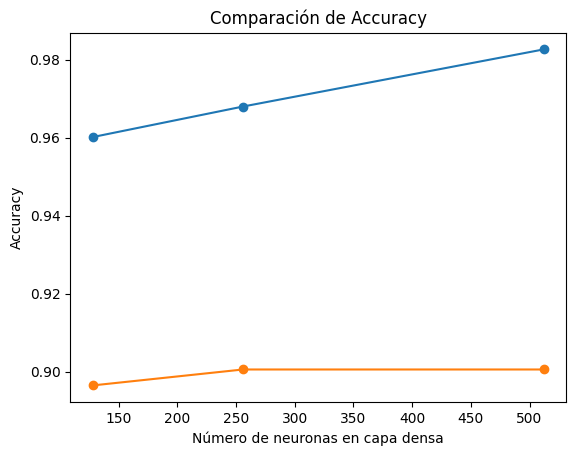

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

input_shape = (299, 299, 3)
epochs = 10
learning_rate = 1e-4

numero_de_nodos = [128, 256, 512]
resultados = []

for nodos in numero_de_nodos:

    print(f"\nEntrenando modelo con Dense({nodos})\n")

    # Base model
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Congelar base
    for layer in base_model.layers:
        layer.trainable = False

    # Construcción correcta del modelo
    x = base_model.output
    x = GlobalAveragePooling2D()(x)   # OBLIGATORIO
    x = Dense(nodos, activation='relu')(x)   # Aquí sí usamos el hiperparámetro
    out_layer = Dense(5, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=out_layer)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',  # Muy importante
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    overfitting_gap = train_acc - val_acc

    resultados.append({
        "Numero de Neuronas": nodos,
        "Entrenamiento Accuracy": train_acc,
        "Validacion Accuracy": val_acc,
        "Overfitting ": overfitting_gap
    })

# Resultados
results_df = pd.DataFrame(resultados)
print("\nResultados comparativos:\n")
print(results_df)

# Gráfico
plt.figure()
plt.plot(results_df["Dense Units"], results_df["Train Accuracy"], marker='o')
plt.plot(results_df["Dense Units"], results_df["Validation Accuracy"], marker='o')
plt.xlabel("Número de neuronas en capa densa")
plt.ylabel("Accuracy")
plt.title("Comparación de Accuracy")
plt.show()

#### 2. Calibración de hiper-parámetros de gradiente descendiente [20 puntos]
Partiendo del modelo estimado del Punto 1, realice la calibración de otros hiper-parámetros relacionados con el algoritmo de gradiente desciente. Puede probar con la selección del optimizador o el uso de estrategias de regularización como, por ejemplo, una capa de _dropout_ antes de la capa de salida.

In [28]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
import pandas as pd

# -----------------------------
# Parámetros generales
# -----------------------------
input_shape = (299, 299, 3)
epochs = 10
nodos = 256   # Usa el mejor del punto anterior

# Optimizadores (IMPORTANTE: como funciones)
optimizadores = {
    "Adam": lambda: Adam(learning_rate=1e-4),
    "RMSprop": lambda: RMSprop(learning_rate=1e-4)
}

usar_dropout = [False, True]
valores_l2 = [0.0, 0.01]

resultados = []

# -----------------------------
# Loop de experimentos
# -----------------------------
for nombre_opt, opt_fn in optimizadores.items():
    for dropout_flag in usar_dropout:
        for l2_value in valores_l2:

            print(f"\nOpt: {nombre_opt} | Dropout: {dropout_flag} | L2: {l2_value}\n")

            # Crear modelo base
            base_model = InceptionV3(
                weights='imagenet',
                include_top=False,
                input_shape=input_shape
            )

            # Congelar base
            base_model.trainable = False

            # Construcción del modelo
            x = base_model.output
            x = GlobalAveragePooling2D()(x)

            x = Dense(
                nodos,
                activation='relu',
                kernel_regularizer=l2(l2_value)
            )(x)

            if dropout_flag:
                x = Dropout(0.5)(x)

            output = Dense(
                5,
                activation='softmax',
                kernel_regularizer=l2(l2_value)
            )(x)

            model = Model(inputs=base_model.input, outputs=output)

            # Crear NUEVO optimizador
            optimizer = opt_fn()

            model.compile(
                optimizer=optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                verbose=1
            )

            train_acc = history.history['accuracy'][-1]
            val_acc = history.history['val_accuracy'][-1]
            gap = train_acc - val_acc

            resultados.append({
                "Optimizador": nombre_opt,
                "Dropout": dropout_flag,
                "L2": l2_value,
                "Train Accuracy": train_acc,
                "Validation Accuracy": val_acc,
                "Overfitting Gap": gap
            })

# -----------------------------
# Resultados finales
# -----------------------------
results_df = pd.DataFrame(resultados)

print("\nResultados ordenados por mejor Validation Accuracy:\n")
print(results_df.sort_values(by="Validation Accuracy", ascending=False))



Opt: Adam | Dropout: False | L2: 0.0

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 809ms/step - accuracy: 0.5961 - loss: 1.0586 - val_accuracy: 0.8229 - val_loss: 0.4965
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 811ms/step - accuracy: 0.8605 - loss: 0.4371 - val_accuracy: 0.8624 - val_loss: 0.3990
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 834ms/step - accuracy: 0.8977 - loss: 0.3337 - val_accuracy: 0.8828 - val_loss: 0.3542
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 812ms/step - accuracy: 0.9130 - loss: 0.2828 - val_accuracy: 0.8842 - val_loss: 0.3311
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 809ms/step - accuracy: 0.9281 - loss: 0.2478 - val_accuracy: 0.8883 - val_loss: 0.3087
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 809ms/step - accuracy: 0.9444 - loss: 0.2124 - val_accuracy: 0.8856 - val_loss: 0.3015
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 813ms/step - accuracy: 0.9495 - loss: 0.1928 - val_accuracy: 0.9005 - val_loss: 0.2957
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 815ms/step - acc

#### 3. Comparación con modelos VGG16 sin _transfer learning_ [20 puntos]
Para revisar si hacer _transfer learning_ tiene alguna utilidad en el modelo, ahora deberá estimar todos los parámetros de la red VGG16 (con todos los parámetros estimables), tenga en cuenta que esto puede tardar bastante. Compare los resultados en la muestra de validación.

In [33]:
batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


In [49]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import pandas as pd

# Parámetros
input_shape = (224, 224, 3)
epochs = 10
learning_rate = 1e-4
print("\nEntrenando VGG16 \n")

# Base model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)


base_model.trainable = True

# Construcción del modelo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
gap = train_acc - val_acc

print("\nResultados:")
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Overfitting Gap:", gap)


Entrenando VGG16 



Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 14,847,301 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 705ms/step - accuracy: 0.5829 - loss: 1.0604 - val_accuracy: 0.7657 - val_loss: 0.6942
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 689ms/step - accuracy: 0.8423 - loss: 0.4385 - val_accuracy: 0.8392 - val_loss: 0.4483
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 693ms/step - accuracy: 0.8757 - loss: 0.3322 - val_accuracy: 0.8460 - val_loss: 0.4612
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 693ms/step - accuracy: 0.9104 - loss: 0.2456 - val_accuracy: 0.8869 - val_loss: 0.3448
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 692ms/step - accuracy: 0.9202 - loss: 0.1998 - val_accuracy: 0.9046 - val_loss: 0.2684
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 691ms/step - accuracy: 0.9453 - loss: 0.1465 - val_accuracy: 0.8910 - val_loss: 0.4040
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 690ms/step - accuracy: 0.9469 - loss: 0.1365 - val_accuracy: 0.8924 - val_loss: 0.4054
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 692ms/step - accuracy: 0.9541 - loss: 0.1293 - val_accu

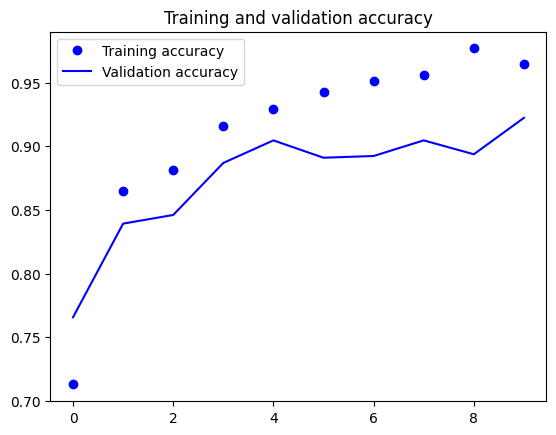

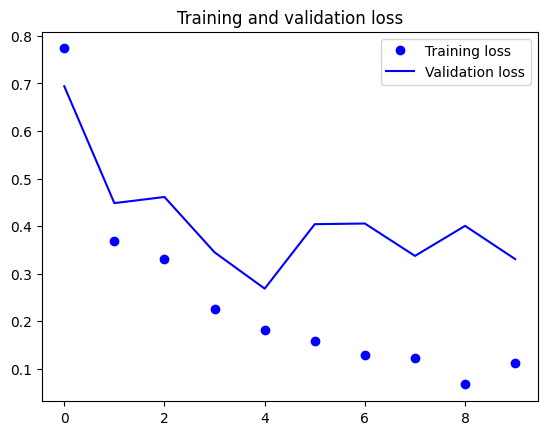

In [51]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

#### 4. _Transfer learning_ con reuso de parámetros (_fine tunning_) [30 puntos]
En la práctica es común que después de hacer _transfer learning_, los parámetros de la red, o de algunas de las últimas capas que no se habían entrenado se liberan para que sean entrenadas.

Acá, debe tomar la red que estimó en el Punto 2 por _transfer learning_ y tomar esta solución como los valores iniciales de una nueva red, en la cual simplemente se dejan entrenables las dos últimas capas de InceptionV3 que se habían dejado no entrenables.

Compare los resultados con los modelos anteriores.

In [59]:
batch_size = 32
img_height = 299
img_width = 299

train_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  extracted_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [68]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [69]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint

input_shape = (299, 299, 3)

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
output = Dense(5, activation='softmax', kernel_regularizer=l2(0.01))(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=RMSprop(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔥 Guardar el mejor modelo automáticamente
checkpoint = ModelCheckpoint(
    "mejor_modelo_punto2.weights.h5",  # 👈 cambiar aquí
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.2654 - loss: 5.7273
Epoch 1: val_accuracy improved from -inf to 0.33651, saving model to mejor_modelo_punto2.weights.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 826ms/step - accuracy: 0.2656 - loss: 5.7228 - val_accuracy: 0.3365 - val_loss: 4.5250
Epoch 2/10
35/92 ━━━━━━━━━━━━━━━━━━━━ 40s 715ms/step - accuracy: 0.3645 - loss: 4.3757

KeyboardInterrupt: 

In [56]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.regularizers import l2

# Parámetros
input_shape = (299, 299, 3)
epochs = 5
learning_rate = 1e-4
nodos = 256


base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Congelar todo primero
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(nodos, activation='relu', kernel_regularizer=l2(0.01))(x)
output = Dense(5, activation='softmax', kernel_regularizer=l2(0.01))(x)

model = Model(inputs=base_model.input, outputs=output)


for layer in base_model.layers[-2:]:
    layer.trainable = True

# Verificar
print("Capas entrenables:")
for layer in base_model.layers[-5:]:
    print(layer.name, layer.trainable)


model.compile(
    optimizer=RMSprop(learning_rate=learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

# Resultados
train_acc = history_ft.history['accuracy'][-1]
val_acc = history_ft.history['val_accuracy'][-1]
gap = train_acc - val_acc

print("\nResultados Fine-Tuning:")
print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Overfitting Gap:", gap)

Capas entrenables:
activation_1777 False
mixed9_1 False
concatenate_37 False
activation_1785 True
mixed10 True
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 800ms/step - accuracy: 0.2698 - loss: 11.6445 - val_accuracy: 0.2602 - val_loss: 9.1931
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 826ms/step - accuracy: 0.3554 - loss: 7.8042 - val_accuracy: 0.3174 - val_loss: 7.5127
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 797ms/step - accuracy: 0.3844 - loss: 7.0923 - val_accuracy: 0.3406 - val_loss: 6.9785
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 807ms/step - accuracy: 0.4223 - loss: 6.3152 - val_accuracy: 0.2875 - val_loss: 8.1638
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 802ms/step - accuracy: 0.4289 - loss: 5.9865 - val_accuracy: 0.4005 - val_loss: 5.8370

Resultados Fine-Tuning:
Train Accuracy: 0.41416892409324646
Validation Accuracy: 0.4005449712276459
Overfitting Gap: 0.013623952865600586
